In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

DATA_PATH = "/content/MobiFall_All.csv"
df = pd.read_csv(DATA_PATH)

df = df.sort_values(['subject_id','trial_number','timestamp']).reset_index(drop=True)
df['t_seconds'] = df['timestamp'] / 1e9

df_acc  = df[df['sensor_type'] == 'acc'].reset_index(drop=True)
df_gyro = df[df['sensor_type'] == 'gyro'].reset_index(drop=True)
df_ori  = df[df['sensor_type'] == 'ori'].reset_index(drop=True)

df_acc = df_acc[['timestamp','x','y','z','subject_id','trial_number','category']]
df_gyro = df_gyro[['timestamp','x','y','z','subject_id','trial_number','category']]
df_ori = df_ori[['timestamp','azimuth','pitch','roll','subject_id','trial_number','category']]


print("Accelerometer shape:", df_acc.shape)
print("Gyroscope shape:", df_gyro.shape)
print("Orientation shape:", df_ori.shape)


Accelerometer shape: (62505, 7)
Gyroscope shape: (104577, 7)
Orientation shape: (80728, 7)


In [ ]:

print("=== Accelerometer ===")
print(df_acc.isnull().sum())
print("\nCategory counts:")
print(df_acc['category'].value_counts())
print("\n")

print("=== Gyroscope ===")
print(df_gyro.isnull().sum())
print("\nCategory counts:")
print(df_gyro['category'].value_counts())
print("\n")

print("=== Orientation ===")
print(df_ori.isnull().sum())
print("\nCategory counts:")
print(df_ori['category'].value_counts())
print("\n")


=== Accelerometer ===
timestamp       0
x               0
y               0
z               0
subject_id      0
trial_number    0
category        0
dtype: int64

Category counts:
category
ADL     52689
FALL     9816
Name: count, dtype: int64


=== Gyroscope ===
timestamp       0
x               0
y               0
z               0
subject_id      0
trial_number    0
category        0
dtype: int64

Category counts:
category
ADL     80589
FALL    23988
Name: count, dtype: int64


=== Orientation ===
timestamp       0
azimuth         0
pitch           0
roll            0
subject_id      0
trial_number    0
category        0
dtype: int64

Category counts:
category
ADL     57218
FALL    23510
Name: count, dtype: int64




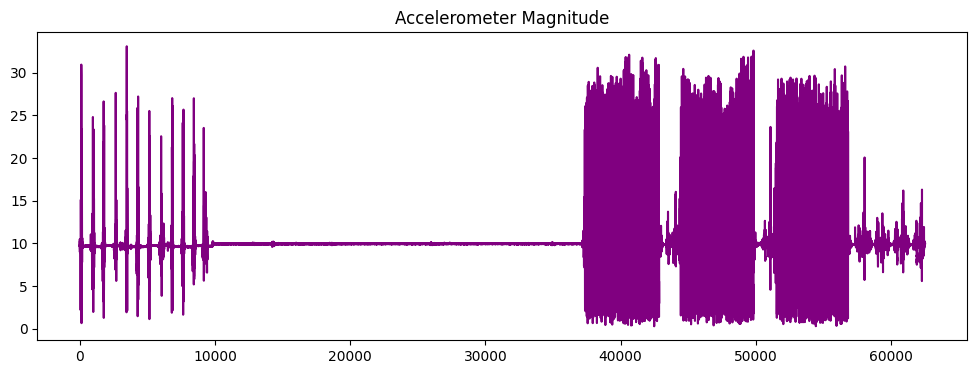

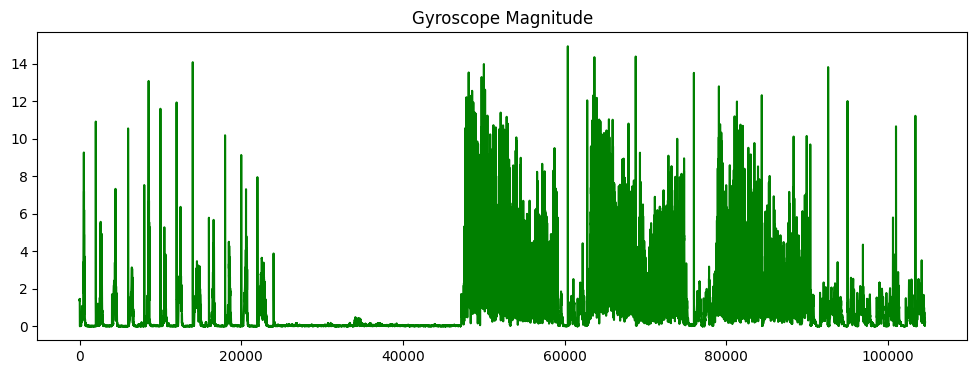

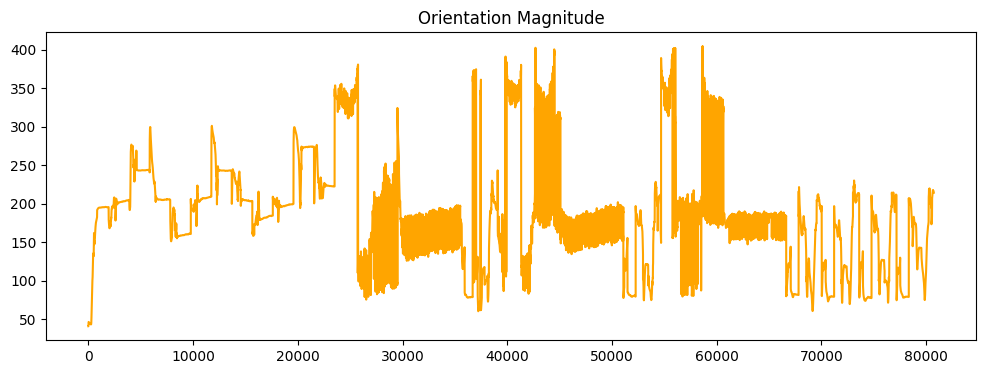

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
df_acc['magnitude'] = np.sqrt(df_acc['x']**2 + df_acc['y']**2 + df_acc['z']**2)
df_gyro['magnitude'] = np.sqrt(df_gyro['x']**2 + df_gyro['y']**2 + df_gyro['z']**2)
df_ori['magnitude'] = np.sqrt(df_ori['azimuth']**2 + df_ori['pitch']**2 + df_ori['roll']**2)


plt.figure(figsize=(12,4))
plt.plot(df_acc['magnitude'].values, color='purple')
plt.title('Accelerometer Magnitude')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_gyro['magnitude'].values, color='green')
plt.title('Gyroscope Magnitude')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_ori['magnitude'].values, color='orange')
plt.title('Orientation Magnitude')
plt.show()


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

X = df_acc.drop(columns=['category'])
y_true = df_acc['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = IsolationForest(contamination=0.05, random_state=42)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))

Accuracy: 0.8072154227661787
Precision: 0.14267434420985284
Recall: 0.0454360228198859
F1 Score: 0.06892288672539021
AUC: 0.497285757998415
[[50009  2680]
 [ 9370   446]]
Total falls:  3126


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

X = df_gyro.drop(columns=['category'])
y_true = df_gyro['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = IsolationForest(contamination=0.05, random_state=42)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))

Accuracy: 0.7414441033879342
Precision: 0.2082616179001721
Recall: 0.04539769884942471
F1 Score: 0.07454564123626656
AUC: 0.4970129617725514
[[76449  4140]
 [22899  1089]]
Total falls:  5229


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

X = df_ori.drop(columns=['category'])
y_true = df_ori['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = IsolationForest(contamination=0.05, random_state=42)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))

Accuracy: 0.7004385095629769
Precision: 0.41664602427545205
Recall: 0.0715440238196512
F1 Score: 0.12211856100482811
AUC: 0.5151928235425286
[[54863  2355]
 [21828  1682]]
Total falls:  4037


one class svm

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

X = df_acc.drop(columns=['category'])
y_true = df_acc['category'].apply(lambda x: 1 if x == 'FALL' else 0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
y_pred = model.fit_predict(X_scaled)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))


Accuracy: 0.8180945524358051
Precision: 0.25175718849840256
Recall: 0.08027709861450692
F1 Score: 0.1217364436891704
F2 Score: 0.0929376798603576
AUC: 0.5179137965125525
[[50347  2342]
 [ 9028   788]]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

X = df_gyro.drop(columns=['category'])
y_true = df_gyro['category'].apply(lambda x: 1 if x == 'FALL' else 0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
y_pred = model.fit_predict(X_scaled)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))


Accuracy: 0.7352285875479312
Precision: 0.14610824249378465
Recall: 0.03184925796231449
F1 Score: 0.05229831947154054
F2 Score: 0.03775412379794625
AUC: 0.4882223371050947
[[76124  4465]
 [23224   764]]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

X = df_ori.drop(columns=['category'])
y_true = df_ori['category'].apply(lambda x: 1 if x == 'FALL' else 0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
y_pred = model.fit_predict(X_scaled)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))


Accuracy: 0.6858834605093648
Precision: 0.2711738484398217
Recall: 0.04657592513823905
F1 Score: 0.07949760418179178
F2 Score: 0.0558229164542507
AUC: 0.49757053099164394
[[54275  2943]
 [22415  1095]]


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

def run_lof(df):
    X = df.drop(columns=['category'])
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0)
    X_scaled = StandardScaler().fit_transform(X)
    model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    y_pred = model.fit_predict(X_scaled)
    y_pred = [1 if p == -1 else 0 for p in y_pred]
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("-"*50)
    print()

print("Accelerometer:")
run_lof(df_acc)

print("Gyroscope:")
run_lof(df_gyro)

print("Orientation:")
run_lof(df_ori)


Accelerometer:
Accuracy: 0.8362690984721223
Precision: 0.4331413947536788
Recall: 0.13793806030969846
F1 Score: 0.20924123010353887
AUC: 0.5521533760334956
[[50917  1772]
 [ 8462  1354]]
--------------------------------------------------

Gyroscope:
Accuracy: 0.7634757164577297
Precision: 0.42857142857142855
Recall: 0.09342171085542772
F1 Score: 0.15340384023000309
AUC: 0.5281723452091976
[[77601  2988]
 [21747  2241]]
--------------------------------------------------

Orientation:
Accuracy: 0.6943191953225647
Precision: 0.3554619767153827
Recall: 0.0610378562313909
F1 Score: 0.10418557374668748
AUC: 0.5077813280597689
[[54616  2602]
 [22075  1435]]
--------------------------------------------------



In [ ]:
import numpy as np
import stumpy
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, fbeta_score, accuracy_score, confusion_matrix

def run_matrix_profile(df, window=100):
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0).values
    signal = df['magnitude'].values
    mp = stumpy.stump(signal, m=window)
    mp_values = mp[:, 0]
    threshold = np.percentile(mp_values, 95)
    y_pred = (mp_values > threshold).astype(int)
    y_true = y_true[:len(y_pred)]
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
    print("AUC:", roc_auc_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("-"*50)

print("Accelerometer:")
run_matrix_profile(df_acc)

print("Gyroscope:")
run_matrix_profile(df_gyro)

print("Orientation:")
run_matrix_profile(df_ori)


Accelerometer:
Accuracy: 0.8037848924782873
Precision: 0.11086190323614226
Recall: 0.03524857375713122
F1 Score: 0.05348998995130247
F2 Score: 0.04081632653061224
AUC: 0.4912409440377214
[[49815  2775]
 [ 9470   346]]
--------------------------------------------------
Gyroscope:
Accuracy: 0.8038247286510078
Precision: 0.8342266462480857
Recall: 0.1816741704185426
F1 Score: 0.2983705326578119
F2 Score: 0.21536728077805012
AUC: 0.5854575349545813
[[79624   866]
 [19630  4358]]
--------------------------------------------------
Orientation:
Accuracy: 0.6608168276922696
Precision: 0.024057539682539684
Recall: 0.004125903870693322
F1 Score: 0.0070437876697407595
F2 Score: 0.004945346276205237
AUC: 0.4676173208843829
[[53184  3935]
 [23413    97]]
--------------------------------------------------


In [ ]:
#deep learning models

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

def run_autoencoder(df):
    X = df.drop(columns=['category'])
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0)
    X_scaled = StandardScaler().fit_transform(X)

    input_dim = X_scaled.shape[1]
    encoding_dim = input_dim // 2

    autoencoder = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(encoding_dim, activation='relu'),
        layers.Dense(input_dim, activation='sigmoid')
    ])

    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(X_scaled, X_scaled, epochs=20, batch_size=128, verbose=0)

    recon = autoencoder.predict(X_scaled)
    mse = np.mean(np.square(X_scaled - recon), axis=1)
    threshold = np.percentile(mse, 95)
    y_pred = (mse > threshold).astype(int)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
    print("AUC:", roc_auc_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("-"*50)

print("Accelerometer:")
run_autoencoder(df_acc)

print("Gyroscope:")
run_autoencoder(df_gyro)

print("Orientation:")
run_autoencoder(df_ori)


Accelerometer:
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step
Accuracy: 0.8246540276777857
Precision: 0.3170185540626999
Recall: 0.10095762021189894
F1 Score: 0.1531447998763715
F2 Score: 0.11689077612644491
AUC: 0.5302184141978852
[[50554  2135]
 [ 8825   991]]
--------------------------------------------------
Gyroscope:
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 2s 630us/step
Accuracy: 0.7249395182497107
Precision: 0.04322050105182635
Recall: 0.009421377355344339
F1 Score: 0.015470445288701784
F2 Score: 0.011168104683685672
AUC: 0.4736704722709666
[[75586  5003]
 [23762   226]]
--------------------------------------------------
Orientation:
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 2s 642us/step
Accuracy: 0.6977380834406898
Precision: 0.3896457765667575
Recall: 0.06690769885155252
F1 Score: 0.11420481359131666
F2 Score: 0.08019209396698512
AUC: 0.5119221635926468
[[54754  2464]
 [21937  1573]]
--------------------------------------------------


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, ops
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=-1))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": reconstruction_loss, "kl_loss": kl_loss}

def run_vae(df):
    X = df.drop(columns=['category'])
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0)
    X_scaled = StandardScaler().fit_transform(X)
    input_dim = X_scaled.shape[1]
    latent_dim = 3

    # Encoder
    inputs = keras.Input(shape=(input_dim,))
    h = layers.Dense(64, activation='relu')(inputs)
    z_mean = layers.Dense(latent_dim)(h)
    z_log_var = layers.Dense(latent_dim)(h)

    def sampling(args):
        z_mean, z_log_var = args
        epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])
    encoder = keras.Model(inputs, [z_mean, z_log_var, z])

    # Decoder
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(latent_inputs)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder = keras.Model(latent_inputs, outputs)

    vae = VAE(encoder, decoder)
    vae.compile(optimizer=keras.optimizers.Adam())
    vae.fit(X_scaled, epochs=20, batch_size=128, verbose=0)

    # Reconstruction
    z_mean, z_log_var, z = encoder.predict(X_scaled)
    recon = decoder.predict(z)
    mse = np.mean(np.square(X_scaled - recon), axis=1)
    threshold = np.percentile(mse, 95)
    y_pred = (mse > threshold).astype(int)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
    print("AUC:", roc_auc_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("-"*50)

print("Accelerometer:")
run_vae(df_acc)

print("Gyroscope:")
run_vae(df_gyro)

print("Orientation:")
run_vae(df_ori)


Accelerometer:
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step
Accuracy: 0.8158547316214703
Precision: 0.2290467050543826
Recall: 0.07294213528932356
F1 Score: 0.11064750424972956
F2 Score: 0.08445388063222459
AUC: 0.5136010188678772
[[50279  2410]
 [ 9100   716]]
--------------------------------------------------
Gyroscope:
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 2s 726us/step
3269/3269 ━━━━━━━━━━━━━━━━━━━━ 2s 691us/step
Accuracy: 0.7239450357153102
Precision: 0.03327596098680436
Recall: 0.007253626813406703
F1 Score: 0.011910873806345621
F2 Score: 0.008598452278589854
AUC: 0.4722639723241735
[[75534  5055]
 [23814   174]]
--------------------------------------------------
Orientation:
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 2s 720us/step
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 2s 931us/step
Accuracy: 0.6818080467743534
Precision: 0.230369085954917
Recall: 0.03955763504891536
F1 Score: 0.06752096417032707
F2 Score: 0.047411727520213706
AUC: 0.492628270493803
[[54111  31

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

def run_cnn_lstm(df, seq_len=50):
    X = df.drop(columns=['category'])
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0)
    X_scaled = StandardScaler().fit_transform(X)
    n_features = X_scaled.shape[1]
    n_seq = len(X_scaled) // seq_len
    X_seq = X_scaled[:n_seq * seq_len].reshape((n_seq, seq_len, n_features))
    y_seq = y_true[:n_seq * seq_len].values.reshape((n_seq, seq_len))
    y_seq = (np.mean(y_seq, axis=1) > 0).astype(int)

    model = models.Sequential([
        layers.Conv1D(64, 3, activation='relu', padding='same', input_shape=(seq_len, n_features)),
        layers.MaxPooling1D(2),
        layers.LSTM(64, return_sequences=False),
        layers.RepeatVector(seq_len),
        layers.LSTM(64, return_sequences=True),
        layers.Conv1DTranspose(64, 3, activation='relu', padding='same'),
        # Removed UpSampling1D(2)
        layers.Conv1D(n_features, 3, activation='sigmoid', padding='same')
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_seq, X_seq, epochs=20, batch_size=64, verbose=0)

    recon = model.predict(X_seq)
    mse = np.mean(np.square(X_seq - recon), axis=(1, 2))
    threshold = np.percentile(mse, 95)
    y_pred = (mse > threshold).astype(int)

    print("Accuracy:", accuracy_score(y_seq, y_pred))
    print("Precision:", precision_score(y_seq, y_pred))
    print("Recall:", recall_score(y_seq, y_pred))
    print("F1 Score:", f1_score(y_seq, y_pred))
    print("F2 Score:", fbeta_score(y_seq, y_pred, beta=2))
    print("AUC:", roc_auc_score(y_seq, y_pred))
    print(confusion_matrix(y_seq, y_pred))
    print("-"*50)

print("Accelerometer:")
run_cnn_lstm(df_acc)

print("Gyroscope:")
run_cnn_lstm(df_gyro)

print("Orientation:")
run_cnn_lstm(df_ori)

Accelerometer:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Accuracy: 0.8608
Precision: 0.6825396825396826
Recall: 0.2182741116751269
F1 Score: 0.33076923076923076
F2 Score: 0.2526439482961222
AUC: 0.5996403796742207
[[1033   20]
 [ 154   43]]
--------------------------------------------------
Gyroscope:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Accuracy: 0.7230989956958394
Precision: 0.02857142857142857
Recall: 0.00625
F1 Score: 0.010256410256410256
F2 Score: 0.007407407407407408
AUC: 0.471467644320298
[[1509  102]
 [ 477    3]]
--------------------------------------------------
Orientation:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Accuracy: 0.7001239157372986
Precision: 0.41975308641975306
Recall: 0.07218683651804671
F1 Score: 0.12318840579710146
F2 Score: 0.08651399491094147
AUC: 0.5155334882502745
[[1096   47]
 [ 437   34]]
--------------------------------------------------


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

def run_tcn(df, seq_len=50):
    X = df.drop(columns=['category'])
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0)
    X_scaled = StandardScaler().fit_transform(X)
    n_features = X_scaled.shape[1]
    n_seq = len(X_scaled) // seq_len
    X_seq = X_scaled[:n_seq * seq_len].reshape((n_seq, seq_len, n_features))
    y_seq = y_true[:n_seq * seq_len].values.reshape((n_seq, seq_len))
    y_seq = (np.mean(y_seq, axis=1) > 0).astype(int)

    # === TCN Autoencoder ===
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(64, 3, dilation_rate=1, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(64, 3, dilation_rate=2, padding='causal', activation='relu')(x)
    x = layers.Conv1D(64, 3, dilation_rate=4, padding='causal', activation='relu')(x)
    encoded = layers.Conv1D(32, 3, dilation_rate=8, padding='causal', activation='relu')(x)

    x = layers.Conv1DTranspose(64, 3, padding='same', activation='relu')(encoded)
    x = layers.Conv1DTranspose(64, 3, padding='same', activation='relu')(x)
    decoded = layers.Conv1D(n_features, 3, padding='same', activation='sigmoid')(x)

    model = models.Model(inp, decoded)
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_seq, X_seq, epochs=25, batch_size=64, verbose=0)

    # === Anomaly detection ===
    recon = model.predict(X_seq)
    mse = np.mean(np.square(X_seq - recon), axis=(1, 2))
    threshold = np.percentile(mse, 95)
    y_pred = (mse > threshold).astype(int)

    print("Accuracy:", accuracy_score(y_seq, y_pred))
    print("Precision:", precision_score(y_seq, y_pred))
    print("Recall:", recall_score(y_seq, y_pred))
    print("F1 Score:", f1_score(y_seq, y_pred))
    print("F2 Score:", fbeta_score(y_seq, y_pred, beta=2))
    print("AUC:", roc_auc_score(y_seq, y_pred))
    print(confusion_matrix(y_seq, y_pred))
    print("-"*50)

print("Accelerometer:")
run_tcn(df_acc)

print("Gyroscope:")
run_tcn(df_gyro)

print("Orientation:")
run_tcn(df_ori)


Accelerometer:
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.8896
Precision: 0.9682539682539683
Recall: 0.3096446700507614
F1 Score: 0.46923076923076923
F2 Score: 0.3584018801410106
AUC: 0.6538726674090464
[[1051    2]
 [ 136   61]]
--------------------------------------------------
Gyroscope:
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy: 0.7221425155428025
Precision: 0.01904761904761905
Recall: 0.004166666666666667
F1 Score: 0.006837606837606838
F2 Score: 0.0049382716049382715
AUC: 0.47011561142147734
[[1508  103]
 [ 478    2]]
--------------------------------------------------
Orientation:
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy: 0.7087980173482032
Precision: 0.5061728395061729
Recall: 0.0870488322717622
F1 Score: 0.14855072463768115
F2 Score: 0.10432569974554708
AUC: 0.5260266033624778
[[1103   40]
 [ 430   41]]
--------------------------------------------------


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

def run_transformer(df, seq_len=50):
    X = df.drop(columns=['category'])
    y_true = df['category'].apply(lambda x: 1 if x == 'FALL' else 0)
    X_scaled = StandardScaler().fit_transform(X)
    n_features = X_scaled.shape[1]
    n_seq = len(X_scaled) // seq_len
    X_seq = X_scaled[:n_seq * seq_len].reshape((n_seq, seq_len, n_features))
    y_seq = y_true[:n_seq * seq_len].values.reshape((n_seq, seq_len))
    y_seq = (np.mean(y_seq, axis=1) > 0).astype(int)

    # === Transformer Autoencoder ===
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32)(inp, inp)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    encoded = layers.Dense(32, activation='relu')(x)

    x = layers.MultiHeadAttention(num_heads=4, key_dim=32)(encoded, encoded)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    decoded = layers.Dense(n_features, activation='sigmoid')(x)

    model = models.Model(inp, decoded)
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_seq, X_seq, epochs=25, batch_size=64, verbose=0)

    recon = model.predict(X_seq)
    mse = np.mean(np.square(X_seq - recon), axis=(1, 2))
    threshold = np.percentile(mse, 95)
    y_pred = (mse > threshold).astype(int)

    print("Accuracy:", accuracy_score(y_seq, y_pred))
    print("Precision:", precision_score(y_seq, y_pred))
    print("Recall:", recall_score(y_seq, y_pred))
    print("F1 Score:", f1_score(y_seq, y_pred))
    print("F2 Score:", fbeta_score(y_seq, y_pred, beta=2))
    print("AUC:", roc_auc_score(y_seq, y_pred))
    print(confusion_matrix(y_seq, y_pred))
    print("-"*50)

print("Accelerometer:")
run_transformer(df_acc)

print("Gyroscope:")
run_transformer(df_gyro)

print("Orientation:")
run_transformer(df_ori)


Accelerometer:
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Accuracy: 0.8864
Precision: 0.9365079365079365
Recall: 0.29949238578680204
F1 Score: 0.45384615384615384
F2 Score: 0.34665099882491185
AUC: 0.6478468576607325
[[1049    4]
 [ 138   59]]
--------------------------------------------------
Gyroscope:
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy: 0.7221425155428025
Precision: 0.01904761904761905
Recall: 0.004166666666666667
F1 Score: 0.006837606837606838
F2 Score: 0.0049382716049382715
AUC: 0.47011561142147734
[[1508  103]
 [ 478    2]]
--------------------------------------------------
Orientation:
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Accuracy: 0.7075588599752168
Precision: 0.49382716049382713
Recall: 0.08492569002123142
F1 Score: 0.14492753623188406
F2 Score: 0.10178117048346055
AUC: 0.5245275869178774
[[1102   41]
 [ 431   40]]
--------------------------------------------------


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import numpy as np

# === Data prep ===
def prepare_gnn_data(df_acc): # Only take accelerometer data for now
    X_acc = StandardScaler().fit_transform(df_acc.drop(columns=['category', 'magnitude', 'timestamp', 'subject_id', 'trial_number'])) # Drop non-feature columns
    y = (df_acc['category'] == 'FALL').astype(int).values
    X = torch.tensor(X_acc, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.long)
    # Create a simple graph where each node represents a sensor reading and connect consecutive readings
    edge_index = torch.tensor([[i, i+1] for i in range(len(df_acc)-1)], dtype=torch.long).t().contiguous()

    return Data(x=X, edge_index=edge_index, y=y)


# === Simple GCN Autoencoder ===
class GCN_AE(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.encoder = GCNConv(in_channels, hidden)
        self.decoder = nn.Linear(hidden, in_channels)

    def forward(self, x, edge_index):
        z = F.relu(self.encoder(x, edge_index))
        recon = self.decoder(z)
        return recon, z

data = prepare_gnn_data(df_acc) # Pass only accelerometer data
model = GCN_AE(data.num_node_features, 64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    recon, _ = model(data.x, data.edge_index)
    loss = F.mse_loss(recon, data.x)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    recon, _ = model(data.x, data.edge_index)
mse = ((data.x - recon) ** 2).mean(dim=1).cpu().numpy()
threshold = np.percentile(mse, 95)
y_pred = (mse > threshold).astype(int)
y_true = data.y.numpy()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.820782337413007
Precision: 0.2783109404990403
Recall: 0.08863080684596578
F1: 0.13444598980064906
AUC: 0.5229067602526817
Confusion Matrix:
 [[50433  2256]
 [ 8946   870]]


In [ ]:
!pip install torch_geometric torch-scatter torch-sparse -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import numpy as np

# === Data prep ===
def prepare_gnn_data(df_acc): # Only take accelerometer data for now
    X_acc = StandardScaler().fit_transform(df_gyro.drop(columns=['category', 'magnitude', 'timestamp', 'subject_id', 'trial_number'])) # Drop non-feature columns
    y = (df_gyro['category'] == 'FALL').astype(int).values
    X = torch.tensor(X_acc, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.long)
    # Create a simple graph where each node represents a sensor reading and connect consecutive readings
    edge_index = torch.tensor([[i, i+1] for i in range(len(df_acc)-1)], dtype=torch.long).t().contiguous()

    return Data(x=X, edge_index=edge_index, y=y)


# === Simple GCN Autoencoder ===
class GCN_AE(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.encoder = GCNConv(in_channels, hidden)
        self.decoder = nn.Linear(hidden, in_channels)

    def forward(self, x, edge_index):
        z = F.relu(self.encoder(x, edge_index))
        recon = self.decoder(z)
        return recon, z

data = prepare_gnn_data(df_acc) # Pass only accelerometer data
model = GCN_AE(data.num_node_features, 64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    recon, _ = model(data.x, data.edge_index)
    loss = F.mse_loss(recon, data.x)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    recon, _ = model(data.x, data.edge_index)
mse = ((data.x - recon) ** 2).mean(dim=1).cpu().numpy()
threshold = np.percentile(mse, 95)
y_pred = (mse > threshold).astype(int)
y_true = data.y.numpy()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.7226445585549404
Precision: 0.02027156244023714
Recall: 0.004418876104719026
F1: 0.007256049560187562
AUC: 0.47042470316298257
Confusion Matrix:
 [[75466  5123]
 [23882   106]]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import numpy as np

# === Data prep ===
def prepare_gnn_data(df_acc): # Only take accelerometer data for now
    X_acc = StandardScaler().fit_transform(df_ori.drop(columns=['category', 'magnitude', 'timestamp', 'subject_id', 'trial_number'])) # Drop non-feature columns
    y = (df_ori['category'] == 'FALL').astype(int).values
    X = torch.tensor(X_acc, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.long)
    # Create a simple graph where each node represents a sensor reading and connect consecutive readings
    edge_index = torch.tensor([[i, i+1] for i in range(len(df_acc)-1)], dtype=torch.long).t().contiguous()

    return Data(x=X, edge_index=edge_index, y=y)


# === Simple GCN Autoencoder ===
class GCN_AE(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.encoder = GCNConv(in_channels, hidden)
        self.decoder = nn.Linear(hidden, in_channels)

    def forward(self, x, edge_index):
        z = F.relu(self.encoder(x, edge_index))
        recon = self.decoder(z)
        return recon, z

data = prepare_gnn_data(df_acc) # Pass only accelerometer data
model = GCN_AE(data.num_node_features, 64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    recon, _ = model(data.x, data.edge_index)
    loss = F.mse_loss(recon, data.x)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    recon, _ = model(data.x, data.edge_index)
mse = ((data.x - recon) ** 2).mean(dim=1).cpu().numpy()
threshold = np.percentile(mse, 95)
y_pred = (mse > threshold).astype(int)
y_true = data.y.numpy()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.6693712218808839
Precision: 0.10601932127817687
Recall: 0.018205019140791152
F1: 0.03107416415580644
AUC: 0.4775652310915952
Confusion Matrix:
 [[53609  3609]
 [23082   428]]
